In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from utils import custom_score, perform_random_search_cv, get_models, score_with_thresh

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

SEED = 3105
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# numbers of features to test
K_VALUES = [2, 3, 4, 5, 6, 7]
# number of random feature subsets
N_RANDOM = 3
# number of random hyperparameter configs per each model
N_ITER = 20
# fraction of a set we are allowed to contact
CONTACT_RATE = 0.2

## Prepare data

In [2]:
data_dir = Path("../../data")
X = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()

with open("../feature_selection/selected_features.txt") as f:
    selected = [s.strip().strip("'").strip('"') for s in f.read().split(",")]

X = X[selected]
print(f"X: {X.shape}")

X: (5000, 30)


In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED
)

X_train.reset_index(drop=True, inplace=True)
X_val.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)

print(f"train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")

train: (3000, 30)  val: (1000, 30)  test: (1000, 30)


## Feature importance and subsets to test

In [45]:
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
ranking = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(
    ascending=False
)
top15 = ranking.index[:15].tolist()


def random_subsets(k, n, excludes):
    seen = {frozenset(e) for e in excludes}
    subsets = []
    while len(subsets) < n:
        s = frozenset(rng.choice(top15, size=k, replace=False))
        if s not in seen:
            seen.add(s)
            subsets.append(sorted(s, key=top15.index))
    return subsets


subsets = {}
for k in K_VALUES:
    topk = ranking.index[:k].tolist()
    topk_1 = ranking.index[1 : k + 1].tolist()
    topk_2 = ranking.index[2 : k + 2].tolist()
    subsets[k] = (
        [("top", topk)]
        + [("top+1", topk_1)]
        + [("top+2", topk_2)]
        + [(f"rand_{i}", s) for i, s in enumerate(random_subsets(k, N_RANDOM, [topk, topk_1,topk_2]))]
    )
    print(f"k={k}: {len(subsets[k])} subsets")

k=2: 6 subsets
k=3: 6 subsets
k=4: 6 subsets
k=5: 6 subsets
k=6: 6 subsets
k=7: 6 subsets


## Random search CV

In [ ]:
results = perform_random_search_cv(X_train, y_train, seed=SEED, k_values=K_VALUES, n_iter=N_ITER, subsets=subsets)

In [24]:
results = pd.read_csv("cv_results_seed_3105.csv")
top = 20
results.head(top)
# the top 20 models have score spread 690 - 615 = 75 points, the average std is ~58 points. 
# Std is nearly as large as the full ranking range - we cannot choose only based on noisy cv estimates. 
# the models here are very similar.

,k,kind,model,cv_score,cv_score_std,features,best_params,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,precision,precision_std
0,2,top+1,RandomForest,690.0,39.370039,"['V191', 'V176']","{'clf__max_depth': 9, 'clf__min_samples_leaf':...",0.573333,0.013768,0.572978,0.013724,0.584844,0.017369
1,2,rand_1,RandomForest,680.0,86.023253,"[np.str_('V191'), np.str_('V416')]","{'clf__max_depth': 11, 'clf__min_samples_leaf'...",0.570333,0.006600,0.569964,0.006607,0.581262,0.006410
2,2,rand_1,LightGBM,670.0,56.124861,"[np.str_('V191'), np.str_('V416')]",{'clf__learning_rate': np.float64(0.0103544993...,0.587667,0.004190,0.587088,0.004110,0.613469,0.004808
3,2,top+1,ExtraTrees,665.0,25.495098,"['V191', 'V176']","{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.588667,0.010625,0.588063,0.010542,0.617720,0.014401
4,2,rand_1,GradientBoosting,660.0,18.708287,"[np.str_('V191'), np.str_('V416')]",{'clf__learning_rate': np.float64(0.0861299091...,0.579667,0.000471,0.579274,0.000548,0.593782,0.005951
5,2,top+1,LightGBM,655.0,32.403703,"['V191', 'V176']",{'clf__learning_rate': np.float64(0.0119796390...,0.567000,0.007874,0.566702,0.007940,0.574919,0.004926
6,2,top,RandomForest,655.0,127.279221,"['V255', 'V191']","{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.567000,0.009092,0.566491,0.009019,0.582719,0.010877
7,2,top,GradientBoosting,650.0,86.023253,"['V255', 'V191']",{'clf__learning_rate': np.float64(0.0187075452...,0.572667,0.013816,0.572142,0.013744,0.591033,0.017313
8,2,top+1,XGBoost,650.0,14.142136,"['V191', 'V176']",{'clf__colsample_bytree': np.float64(0.9781553...,0.574000,0.010708,0.573668,0.010750,0.584321,0.008679
9,2,top,ExtraTrees,640.0,80.311892,"['V255', 'V191']","{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.580000,0.010231,0.579361,0.010179,0.607242,0.010270


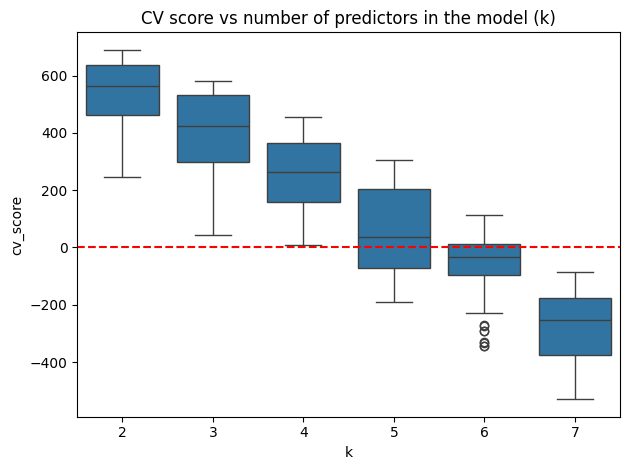

In [25]:
sns.boxplot(data=results, x="k", y="cv_score")
plt.title("CV score vs number of predictors in the model (k)")
plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

## Choosing threshold on val and evaluating on different val/test splits

In [26]:
top20_models = results.head(top)
models = get_models()

In [12]:
seeds = [(2910 + i) for i in range(30)]
ts = np.linspace(0, 0.9, num=30)
per_split = {i: [] for i in range(top)}

X_valte = pd.concat([X_val, X_test], axis=0)
y_valte = pd.concat([pd.DataFrame(y_val), pd.DataFrame(y_test)], axis=0)

for i in range(top):
    k = top20_models["k"].iloc[i]
    features = eval(top20_models["features"].iloc[i])
    params = eval(top20_models["best_params"].iloc[i])
    pipeline = Pipeline([("scaler", StandardScaler()),
                         ("clf", clone(models[top20_models["model"].iloc[i]][0]))])
    pipeline.set_params(**params)
    pipeline.fit(X_train[features], y_train)

    for s in seeds:
        X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
            X_valte, y_valte, test_size=0.5, random_state=s
        )
        y_val_s = y_val_s.to_numpy().ravel()
        y_test_s = y_test_s.to_numpy().ravel()

        proba_val = pipeline.predict_proba(X_val_s[features])[:, 1]
        best_t, best_val = 0.0, -np.inf
        for t in ts:
            score, _ = score_with_thresh(y_val_s, proba_val, n_var=k, thresh=t)
            if score >= best_val:
                best_val, best_t = score, t

        proba_te = pipeline.predict_proba(X_test_s[features])[:, 1]
        precision_test = precision_score(y_test_s, proba_te >= best_t)
        test_sc, test_contacts = score_with_thresh(y_test_s, proba_te, n_var=k, thresh=best_t)

        per_split[i].append({"seed": s, "val_thresh": best_t,
                             "val_score": best_val, "test_score": test_sc,
                             "contacts": test_contacts, "precision_test": precision_test})

In [13]:
rows = []
for i in range(top):
    d = pd.DataFrame(per_split[i])
    name = f"{top20_models['model'].iloc[i]} {i + 1}"
    thresh_mean, thresh_std = d["val_thresh"].mean(), d["val_thresh"].std(ddof=1)
    prec_mean, prec_std = d["precision_test"].mean(), d["precision_test"].std(ddof=1)
    vmean, vstd = d["val_score"].mean(), d["val_score"].std(ddof=1)
    tmean, tstd = d["test_score"].mean(), d["test_score"].std(ddof=1)
    rows.append({
        "model": name,
        "k": int(top20_models["k"].iloc[i]),
        "cv": top20_models["cv_score"].iloc[i],
        "mean_val_thresh": round(thresh_mean, 4),
        "std_val_thresh": round(thresh_std, 3),
        "val_mean": round(vmean, 1),
        "val_std": round(vstd, 1),
        "test_mean": round(tmean, 1),
        "test_std": round(tstd, 1),
        "test_min": d["test_score"].min(),
        "test_max": d["test_score"].max(),
        "criterion": round(tmean - tstd, 1),
        "prec_test_mean": round(prec_mean,3),
        "pred_test_std": round(prec_std,3),
        "med_contacts": int(d["contacts"].median()),
    })

summary = pd.DataFrame(rows).sort_values("criterion", ascending=False)
summary

,model,k,cv,mean_val_thresh,std_val_thresh,val_mean,val_std,test_mean,test_std,test_min,test_max,criterion,prec_test_mean,pred_test_std,med_contacts
14,SVM_RBF 15,2,630.0,0.5969,0.013,714.5,88.1,713.2,95.4,505,910,617.8,0.698,0.029,200
15,ExtraTrees 16,2,630.0,0.4966,0.000,693.5,73.5,695.5,77.8,565,895,617.7,0.577,0.018,200
3,ExtraTrees 4,2,665.0,0.5328,0.012,682.2,84.3,689.7,101.0,505,910,588.6,0.671,0.028,200
18,SVM_RBF 19,2,615.0,0.5638,0.012,676.2,78.7,667.3,84.6,520,850,582.7,0.671,0.028,200
2,LightGBM 3,2,670.0,0.5762,0.032,629.5,59.9,643.7,68.9,505,775,574.7,0.670,0.034,200
12,ExtraTrees 13,2,635.0,0.4966,0.000,601.5,78.4,629.5,65.2,505,775,564.3,0.632,0.017,200
9,ExtraTrees 10,2,640.0,0.5276,0.000,647.0,82.2,635.0,76.8,490,790,558.2,0.640,0.024,200
10,SVM_RBF 11,2,640.0,0.6207,0.000,612.0,80.9,630.3,74.5,475,820,555.9,0.673,0.023,200
4,GradientBoosting 5,2,660.0,0.5907,0.006,611.0,70.8,632.3,77.9,455,775,554.5,0.671,0.020,200
16,RandomForest 17,2,630.0,0.5328,0.012,644.0,74.0,633.0,84.8,445,760,548.2,0.642,0.029,200


## Final model and test prediction

In [37]:
data_dir = Path("../../data")
X_train = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y_train = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()
X_test = pd.read_csv(data_dir / "x_test.txt", sep=" ")

In [40]:
print(f"Final model: {top20_models['model'].iloc[15]} {15 + 1}")
features = eval(top20_models["features"].iloc[15])
print(f"Chosen features: {features}")
params = eval(top20_models["best_params"].iloc[15])
print(f"Parameters: {params}")

et = ExtraTreesClassifier(max_depth=4, min_samples_leaf=9, n_estimators=403, random_state=SEED)
pipeline = Pipeline([("scaler", StandardScaler()), ("clf", et)])
pipeline.fit(X_train[features], y_train)

Final model: ExtraTrees 16
Chosen features: ['V176', 'V380']
Parameters: {'clf__max_depth': 4, 'clf__min_samples_leaf': 9, 'clf__n_estimators': 403}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",403
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [41]:
print("Measures for train set")
top = 1000
pred_train = pipeline.predict_proba(X_train[features])[:, 1]
order = np.argsort(-pred_train)
p_sorted = pred_train[order]
print("probability at rank 1000:", round(p_sorted[999], 4))
top_indices = np.argsort(pred_train)[-top:]
pred_train = np.zeros(len(y_train))
pred_train[top_indices] = 1

print(f"score: {custom_score(y_train, pred_train, 2)}")
print(f"accuracy: {accuracy_score(y_train, pred_train)}")
print(f"bal acc: {balanced_accuracy_score(y_train, pred_train)}")
print(f"precision: {precision_score(y_train, pred_train)}")

Measures for train set
probability at rank 1000: 0.5127
score: 4995
accuracy: 0.5796
bal acc: 0.5781618008478916
precision: 0.693


### Prediction

In [42]:
pred = pipeline.predict_proba(X_test[features])[:,1]
pred_thresh= (pred >= (0.4966))
print(f"number of contacted clients with validation threshold: {sum(pred_thresh)}")

number of contacted clients with validation threshold: 1882


In [43]:
order = np.argsort(-pred)
p_sorted = pred[order]
print("probability at rank 1000:", round(p_sorted[999], 4))
top = 1000
# indices of top 1000 probabilities
top_indices = np.argsort(pred)[-top:] + 1

probability at rank 1000: 0.5116


In [44]:
top_indices

array([2260, 1872,   19, 2171, 1901,   60,  980, 2346, 3443, 3961, 1931,
       3488, 4724, 2851, 4793,    6, 1801, 3103, 3853, 1383, 3769,  137,
       1650, 2086, 4920, 3329,  235, 3220, 4144, 1580, 4719, 1406, 1002,
       2309, 4071,  310, 2042, 3334,  364,  948, 2106, 1573, 3797,  676,
       2460, 1185,   14,  237, 2082, 1514, 4404, 2369,  187,   15, 4773,
       4625,  712, 4110, 3227,  388, 1762, 4892, 3954, 1893, 4660, 3901,
       1181, 3285, 4708,  411, 4985, 4742, 3884,  304, 4207, 2270, 1977,
       4526, 3225,  741, 1346, 2399,  113, 3118,  427, 2811,  121,  183,
       1619, 1394, 3493, 1993, 1049, 1570, 4599, 3648, 1480, 4386, 1583,
        455, 4817, 4628,  414, 2538,  749,  105,   16, 4698, 3111, 2955,
       1722, 1270, 3155, 2026, 2635, 3807, 3844, 4940, 4150, 2671, 2900,
       2583, 3278, 2485, 4632, 3109, 2628,  333, 1350,  271, 2865, 1966,
       4321, 3920, 3106, 2083,  714, 4444, 2020, 1456, 4171, 3663, 4176,
       2161, 3864, 2676, 3446, 2234, 1460, 2153, 11

### Sanity check, that the distibutions of selected features match on train and test

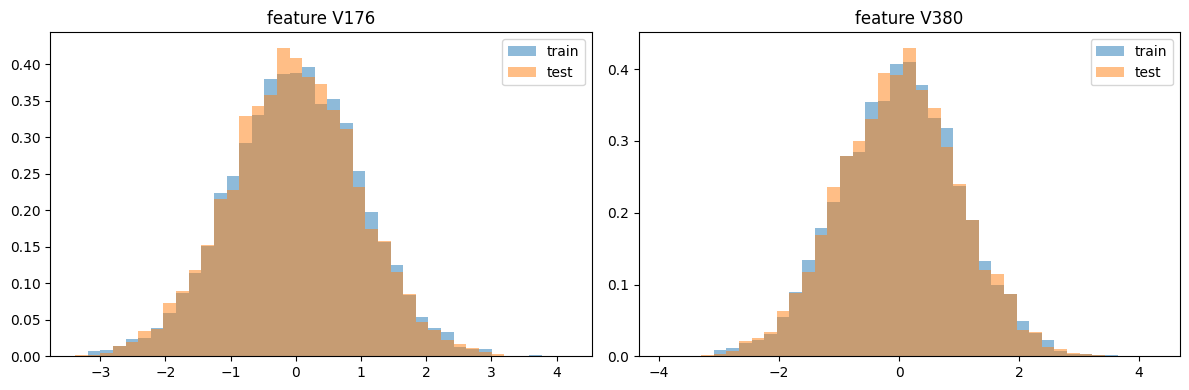

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path("../../data")
x_train = pd.read_csv(data_dir / "x_train.txt", sep=" ")
y_train = pd.read_csv(data_dir / "y_train.txt", sep=" ").values.ravel()
x_test = pd.read_csv(data_dir / "x_test.txt", sep=" ")
features = ['V176', 'V380']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, f in enumerate(features):
    tr = x_train[f]
    te = x_test[f]
    lo = min(tr.min(), te.min())
    hi = max(tr.max(), te.max())
    bins = np.linspace(lo, hi, 40)
    axes[i].hist(tr, bins=bins, density=True, alpha=0.5, label="train")
    axes[i].hist(te, bins=bins, density=True, alpha=0.5, label="test")
    axes[i].set_title(f"feature {f}")
    axes[i].legend()

plt.tight_layout()
plt.show()